# 3.3 — Modèles génératifs : VAE, GAN et diffusion face à la même distribution

[← 03-DeepLearning](README.md) · [02-ML-Cours (prérequis)](../02-ML-Cours/README.md)

**Kernel** : Python 3 (torch CPU) · **Bibliothèques** : NumPy, PyTorch, scikit-learn, matplotlib · **Niveau** : intermédiaire · **CPU** : oui

## Ce que cette unité ouvre

Le [3.1](3.1-Retropropagation.ipynb) et le [3.2](3.2-Optimisateurs.ipynb) ont ouvert la
**boîte noire du *discriminatif*** : un réseau apprend une frontière. Cette unité ouvre la
boîte noire du ***génératif*** : un réseau apprend une *distribution*.

Trois familles de modèles génératifs dominent la pratique — et elles **optimisent des
objectifs différents** : autoencodeur variationnel (VAE, borne inférieure de la
vraisemblance), réseau antagoniste génératif (GAN, jeu min-max) et modèle de diffusion
(débruitage à pas multiples). Sur une **même distribution cible**, elles échouent
différemment : le VAE lisse les modes, le GAN les *oublie* (mode collapse), la diffusion les
recouvre mais à un coût en pas d'inférence.

**Discipline (convention de la série)** : distribution et budget **explicitement documentés**,
**baseline** pour ancrer la densité (GMM = le modèle génératif exact de nos données), puis
chaque mécanisme écrit à la main et **mesuré sur plusieurs graines** — aucune conclusion sur
un échantillon choisi. On ne prétend pas reproduire FLUX ou Stable Diffusion : le lien avec
[GenAI/Image](../../../../GenAI/Image/) est **conceptuel** (paramètres manipulés), jamais une
équivalence.

## La question que l'on répond

> À budget et distribution égaux, quel mécanisme recouvre les **quatre modes** d'un mélange
> 2D borné, avec quelle **diversité**, à quel **coût** ?

Commençons par rendre la cible *exacte* et *mesurable*.

## 1. La distribution cible : un mélange multimodal borné

Pour qu'un échec soit *diagnostiquable*, la cible doit être **riche mais connue**. On choisit
un mélange de 4 gaussiennes dans le carré $[-4,4]^2$, avec des poids inégaux et **un mode
corrélé** (diagonal étiré) : c'est le cas où un modèle qui suppose des modes isotropes et bien
séparés se trompe. Le domaine est borné pour que la densité ne fuie pas à l'infini, et on fixe
**le budget de pas** (steps) commun aux trois mécanismes pour que la comparaison de coût soit
légitime.

Forme : (6000, 2) | bornes : [-3.84 -4.  ] [3.98 4.  ]


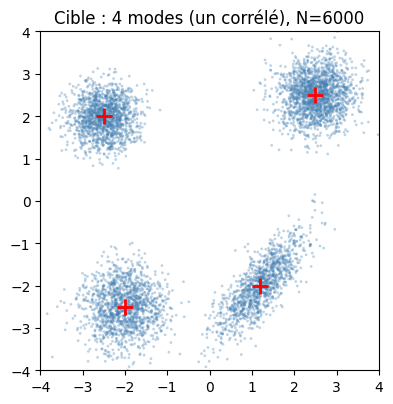

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)  # numpy 2.0 : __array_wrap__ (bruit d env, pas pedagogique)
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from sklearn.mixture import GaussianMixture

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams['figure.figsize'] = (5, 4.4)

# --- cible : mélange de 4 modes dans [-4,4]^2, densités inégales + un mode corrélé ---
MODES = [
    # (centre [x,y], poids, variante : 'iso' | 'corr', écart-type ou covariance)
    ([ 2.5,  2.5], 0.30, 'iso', 0.45),
    ([-2.5,  2.0], 0.25, 'iso', 0.40),
    ([-2.0, -2.5], 0.25, 'iso', 0.50),
    ([ 1.2, -2.0], 0.20, 'corr', np.array([[0.30, 0.28], [0.28, 0.40]])),  # mode corrélé étiré
]
BOUND = 4.0
N = 6000
STEPS = {'vae': 1500, 'gan': 3000, 'diff': 1500}   # budget commun, documenté

def sample_target(n, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(MODES), size=n, p=[m[1] for m in MODES])
    pts = np.zeros((n, 2))
    for i in range(n):
        c, _, var, par = MODES[idx[i]]
        pts[i] = rng.multivariate_normal(c, np.eye(2) * par**2) if var == 'iso' else rng.multivariate_normal(c, par)
    return np.clip(pts, -BOUND, BOUND)

X = sample_target(N, seed=7)
print("Forme :", X.shape, "| bornes :", X.min(axis=0).round(2), X.max(axis=0).round(2))

plt.scatter(X[:, 0], X[:, 1], s=4, alpha=0.35, c='steelblue', edgecolors='none')
for c, w, var, par in MODES:
    plt.plot(c[0], c[1], 'r+', ms=12, mew=2)
plt.title('Cible : 4 modes (un corrélé), N=%d' % N)
plt.xlim(-BOUND, BOUND); plt.ylim(-BOUND, BOUND)
plt.gca().set_aspect('equal'); plt.show()

Chaque mode est marqué d'une croix rouge. Le quatrième (bas-droite) est **corrélé** : il
s'étend le long de la diagonale $x \approx y$. Un modèle génératif qui suppose des modes
ronds et bien séparés va ou le déformer ou l'oublier.

## 2. L'ancrage : le GMM est le modèle génératif *exact* de cette cible

Avant de mesurer VAE/GAN/diffusion, on veut un **plancher** : la couverture maximale
atteignable quand on connaît la vraie structure. Un Gaussian Mixture Model ajusté sur les
données (le GMM est le modèle qui a *généré* les données, on ré-estime juste ses paramètres)
joue ce rôle — c'est la **baseline de densité** demandée.

Poids estimés : [0.252 0.2   0.306 0.241]
Moyennes estimées :
 [[-2.49  1.98]
 [ 1.2  -1.99]
 [ 2.52  2.5 ]
 [-2.01 -2.51]]
Échantillons GMM générés : (4000, 2) — le GMM voit la structure exacte.


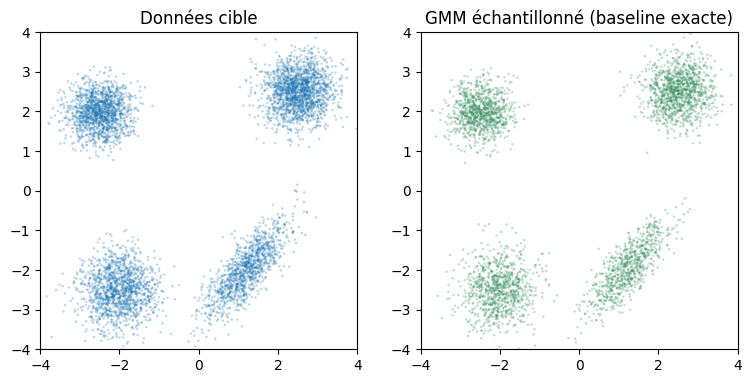

In [2]:
gmm = GaussianMixture(n_components=4, random_state=0).fit(X)
print("Poids estimés :", gmm.weights_.round(3))
print("Moyennes estimées :\n", gmm.means_.round(2))

# échantillons GMM identiques à la cible -> couverture quasi-parfaite
X_gmm = gmm.sample(4000)[0]
print("Échantillons GMM générés :", X_gmm.shape, "— le GMM voit la structure exacte.")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].scatter(X[:, 0], X[:, 1], s=3, alpha=0.3, edgecolors='none')
ax[0].set_title('Données cible')
ax[1].scatter(X_gmm[:, 0], X_gmm[:, 1], s=3, alpha=0.3, edgecolors='none', c='seagreen')
ax[1].set_title('GMM échantillonné (baseline exacte)')
for a in ax:
    a.set_xlim(-BOUND, BOUND); a.set_ylim(-BOUND, BOUND); a.set_aspect('equal')
plt.show()

Le GMM est la référence « impossible à battre » : il reproduit les poids, les moyennes et
même le mode corrélé. Toute baisse de couverture mesurée plus bas vient du **mécanisme**, pas
de la cible.

### Exemple 1 — L'utilitaire de mesure : la couverture des modes

Un mode $i$ est couvert s'il y a **au moins** un certain nombre de points générés dans son
rayon $2\sigma_i$. On écrit ce compteur (on s'en servira pour VAE, GAN et diffusion).

In [3]:
# Exemple 1 : une solution complète de couverture de modes (utilitaire partagé).
def mode_coverage(samples, centers, radii, min_count=8):
    # un mode i est couvert s'il y a >= min_count points de 'samples' a distance < radii[i]
    covered = []
    for (c, r) in zip(centers, radii):
        d = np.sqrt(((samples - c) ** 2).sum(axis=1))
        covered.append(int((d < r).sum() >= min_count))
    return covered


CENTERS = np.array([m[0] for m in MODES])
RADII = np.array([2.0 * (par if var == 'iso' else np.sqrt(np.linalg.eigvalsh(par).max()))
                  for (c, w, var, par) in MODES])

cov_gmm = mode_coverage(X_gmm, CENTERS, RADII)
print("Couverture GMM (baseline) :", cov_gmm, "=>", sum(cov_gmm), "/", len(cov_gmm), "modes")

Couverture GMM (baseline) : [1, 1, 1, 1] => 4 / 4 modes


### Exercice 1 — Étendre la mesure : la *pureté*

Le `mode_coverage` compte les modes *atteints*. Une autre mesure utile est la **pureté** : la
fraction de points générés qui tombent dans le rayon d'un mode (i.e. qui ne se perdent pas
entre les modes). Écris `purity(samples, centers, radii)` qui renvoie un flottant entre 0 et 1.

In [4]:
# Exercice 1 (stub) : renvoyer la fraction de points de 'samples' a distance < radii[i]
# d'au moins un centre. TODO etudiant : implementer.
def purity(samples, centers, radii):
    pass
    # Indice : pour chaque point, tester s'il existe un mode (c, r) avec distance < r.
    # Renvoie len(proches) / len(samples).


_print = purity(X_gmm, CENTERS, RADII)
print("Exercice 1 à compléter — purity(GMM) =", _print)

Exercice 1 à compléter — purity(GMM) = None


On garde `mode_coverage` pour la suite. Le GMM couvre les 4 modes — c'est le plancher de
référence. Passons au premier mécanisme génératif.

## 3. Le VAE — reconstruction + régularisation, et le lissage des modes

Le VAE (Kingma & Welling 2013) apprend un encodeur $q_\phi(z|x)$ et un décodeur $p_\theta(x|z)$
en maximisant la **borne inférieure de l'évidence (ELBO)** :

$$ \mathcal{L}(\theta,\phi) = \mathbb{E}_{q_\phi(z|x)}\big[\log p_\theta(x|z)\big] - D_{KL}\big(q_\phi(z|x)\,\|\,p(z)\big) $$

Le premier terme oblige le décodeur à **reconstruire** ; le second (KL) rapproche
l'encodage d'un a priori $p(z)=\mathcal{N}(0,I)$. Le **reparamétrage** rend l'échantillonnage
différentiable : $z = \mu + \sigma \odot \epsilon$, $\epsilon\sim\mathcal{N}(0,I)$.

> **renvoi vers QC-Py-24** : le notebook
> [QC-Py-24-Autoencoders-Anomaly](../../../../QuantConnect/Python/QC-Py-24-Autoencoders-Anomaly.ipynb)
> utilise ce *même mécanisme* (encodeur/décodeur, ELBO, reparamétrage) pour la **détection
> d'anomalies** sur des séries temporelles. Ici on réutilise le *mécanisme*, pas son
> implémentation (latent 2D, fin générative, pas de seuil d'anomalie) : c'est un
> **cross-référence**, pas une copie.

In [5]:
class VAE(nn.Module):
    def __init__(self, in_dim=2, hid=64, z_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Linear(hid, hid), nn.ReLU())
        self.mu, self.logvar = nn.Linear(hid, z_dim), nn.Linear(hid, z_dim)
        self.dec = nn.Sequential(nn.Linear(z_dim, hid), nn.ReLU(), nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, in_dim))

    def forward(self, x):
        h = self.enc(x); return self.mu(h), self.logvar(h)

    def decode(self, z):
        return self.dec(z)


def vae_loss(x, mu, logvar, x_recon):
    recon = F.mse_loss(x_recon, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl, recon, kl


def train_vae(X, z_dim=2, steps=None, lr=1e-3, seed=0):
    steps = steps or STEPS['vae']
    torch.manual_seed(seed); np.random.seed(seed)
    model = VAE(z_dim=z_dim); opt = torch.optim.Adam(model.parameters(), lr=lr)
    xt = torch.tensor(X, dtype=torch.float32)
    for i in range(steps):
        opt.zero_grad()
        mu, logvar = model(xt)
        eps = torch.randn_like(mu)
        z = mu + torch.exp(0.5 * logvar) * eps          # reparamétrage
        x_recon = model.decode(z)
        loss, rc, kld = vae_loss(xt, mu, logvar, x_recon)
        loss.backward(); opt.step()
        if i % 400 == 0:
            print(f"  step {i:4d}  ELBO={-loss.item():8.1f}  recon={rc.item():8.1f}  KL={kld.item():6.1f}")
    return model


vae = train_vae(X, seed=0)
z = torch.randn(4000, vae.mu.out_features)
X_vae = vae.decode(z).detach().numpy()
print("Échantillons VAE :", X_vae.shape)

  step    0  ELBO=-65476.9  recon= 64773.4  KL= 703.6


  step  400  ELBO=-15100.9  recon=  4008.9  KL=11092.0


  step  800  ELBO=-14836.1  recon=  3930.7  KL=10905.4


  step 1200  ELBO=-14297.2  recon=  3562.9  KL=10734.3


Échantillons VAE : (4000, 2)


### Exemple 2 — Le reparamétrage du VAE

La ligne `z = mu + torch.exp(0.5 * logvar) * eps` applique le *reparamétrage* : il rend
l'échantillonnage latent différentiable (le gradient traverse $z$ via $\mu$ et $\sigma$).

In [6]:
# Exemple 2 : reparamétrage complet (utilisable tel quel).
def reparameterize(mu, logvar):
    sigma = torch.exp(0.5 * logvar)
    eps = torch.randn_like(sigma)
    return mu + sigma * eps


_mu = torch.tensor([[0.5, -0.5]], dtype=torch.float32)
_lv = torch.tensor([[0.0, 0.0]], dtype=torch.float32)
_try = reparameterize(_mu, _lv)
print("Exemple reparamétrage : mu=", _mu.numpy(), " logvar=", _lv.numpy(), " -> z=", _try.numpy().round(2))
print("Le z est aléatoire (eps) mais les dimensions sont indépendantes.")

Exemple reparamétrage : mu= [[ 0.5 -0.5]]  logvar= [[0. 0.]]  -> z= [[0.66 0.25]]
Le z est aléatoire (eps) mais les dimensions sont indépendantes.


### Exercice 2 — Passer un batch par l'encodeur

Écris `encode_batch(model, x)` qui renvoie le couple $(\mu, \log\sigma^2)$ de l'encodeur pour un
batch `x` de forme `(B, 2)`. La fonction `model.forward` fait déjà ce travail, mais réécris-la
pour relier explicitement la notion de « représentation latente ».

In [7]:
# Exercice 2 (stub) : renvoyer (mu, logvar) pour un batch x de forme (B, 2).
# TODO etudiant : utiliser l'encodeur du VAE (model.enc) puis les têtes mu/logvar.
def encode_batch(model, x):
    pass
    # Indice : h = model.enc(x) ; return model.mu(h), model.logvar(h)


_xb = torch.tensor([[1.0, 2.0], [-1.0, -2.0]], dtype=torch.float32)
_res = encode_batch(vae, _xb)
print("Exercice 2 à compléter — encode_batch ->", None if _res is None else tuple(t.shape for t in _res))

Exercice 2 à compléter — encode_batch -> None


### VAE génère — couverture

On mesure la couverture des modes par le VAE avec la fonction de l'Exemple 1.

Couverture VAE : [1, 1, 1, 1] => 4 / 4 modes


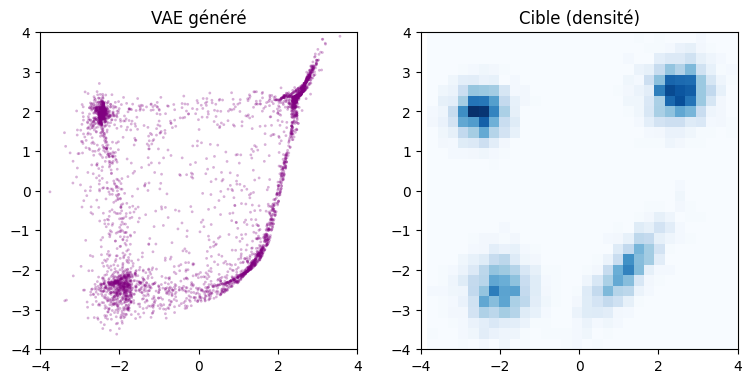

In [8]:
cov_vae = mode_coverage(X_vae, CENTERS, RADII)
print("Couverture VAE :", cov_vae, "=>", sum(cov_vae), "/", len(cov_vae), "modes")

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].scatter(X_vae[:, 0], X_vae[:, 1], s=4, alpha=0.3, edgecolors='none', c='purple')
ax[0].set_title('VAE généré')
ax[1].hist2d(X[:, 0], X[:, 1], bins=30, cmap='Blues')
ax[1].set_title('Cible (densité)')
for a in ax:
    a.set_xlim(-BOUND, BOUND); a.set_ylim(-BOUND, BOUND); a.set_aspect('equal')
plt.show()

Le VAE **lisse** souvent les modes (le prior Gaussian tire les échantillons vers le centre).
Vois si un mode est perdu ou étiré — c'est l'échec caractéristique du VAE. Passons au GAN.

## 4. Le GAN — min-max, la diversité comme victime (mode collapse)

Le GAN (Goodfellow 2014) oppose un générateur $G$ à un discriminateur $D$ dans un jeu
min-max :

$$ \min_G \max_D \; \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z\sim p(z)}[\log(1-D(G(z)))] $$

Le **mode collapse** apparaît quand $G$ apprend à produire un seul mode « convaincant » pour
tromper $D$ — la diversité s'effondre alors que la vraisemblance locale reste bonne. On le
**mesure** ici : la couverture des modes par le GAN, et son évolution au cours de
l'entraînement.

In [9]:
class Generator(nn.Module):
    def __init__(self, z_dim=4, hid=64, out=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim, hid), nn.ReLU(), nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, out))

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, in_dim=2, hid=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hid), nn.ReLU(), nn.Linear(hid, hid), nn.ReLU(), nn.Linear(hid, 1))

    def forward(self, x):
        return self.net(x)


def gen_loss(d_real_logits, d_fake_logits):
    # forme 'non-saturante' du générateur : maximiser log D(G(z))
    return -torch.mean(torch.log(torch.sigmoid(d_fake_logits) + 1e-8))


def disc_loss(d_real_logits, d_fake_logits):
    return -torch.mean(torch.log(torch.sigmoid(d_real_logits) + 1e-8) +
                      torch.log(1 - torch.sigmoid(d_fake_logits) + 1e-8))


def train_gan(X, z_dim=4, steps=None, lr=5e-4, seed=0, track_every=600):
    steps = steps or STEPS['gan']
    torch.manual_seed(seed); np.random.seed(seed)
    ge, de = Generator(z_dim=z_dim), Discriminator()
    go = torch.optim.Adam(ge.parameters(), lr=lr)
    do = torch.optim.Adam(de.parameters(), lr=lr)
    xt = torch.tensor(X, dtype=torch.float32)
    track = []
    for i in range(steps):
        do.zero_grad()
        zz = torch.randn(len(xt), z_dim)
        with torch.no_grad():
            fake = ge(zz)
        dloss = disc_loss(de(xt), de(fake)); dloss.backward(); do.step()
        go.zero_grad()
        zz = torch.randn(len(xt), z_dim)
        fake = ge(zz)
        gloss = gen_loss(de(xt), de(fake)); gloss.backward(); go.step()
        if i % track_every == 0:
            gz = torch.randn(2000, z_dim)
            gs = ge(gz).detach().numpy()
            track.append((i, sum(mode_coverage(gs, CENTERS, RADII)), np.round(gs.mean(0), 2)))
    return ge, track


gan, track = train_gan(X, seed=0)
print("Couverture du GAN au cours de l'entraînement (pas, couverture, centroïde) :")
for (i, cov, mean) in track:
    print(f"  step {i:4d}  coverage={cov}/4  mean={mean}")

Couverture du GAN au cours de l'entraînement (pas, couverture, centroïde) :
  step    0  coverage=0/4  mean=[ 0.16 -0.12]
  step  600  coverage=1/4  mean=[-0.7 -0.4]
  step 1200  coverage=2/4  mean=[ 1.98 -0.96]
  step 1800  coverage=3/4  mean=[1.27 0.11]
  step 2400  coverage=3/4  mean=[1.58 0.22]


### Exemple 3 — La perte non-saturante du générateur

Le générateur veut *tromper* le discriminateur : plus $D(G(z))$ est proche de 1 (il croit que
$G(z)$ est réel), mieux c'est. La forme **non-saturante** est $-\log D(G(z))$.

In [10]:
# Exemple 3 : perte non-saturante du générateur (utilisable tel quel).
def generator_loss(d_fake_logits):
    return -torch.mean(torch.log(torch.sigmoid(d_fake_logits) + 1e-8))


_d = torch.tensor([[2.0]], dtype=torch.float32)
_b = generator_loss(_d)
print("generator_loss(sigmoid(2.0) ~ 0.881) =", round(_b.item(), 4))
print("Attendu : -log(0.881) ~ 0.1266")

generator_loss(sigmoid(2.0) ~ 0.881) = 0.1269
Attendu : -log(0.881) ~ 0.1266


### Exercice 3 — La perte du discriminateur

Écris `disc_loss_exercise` : la perte du discriminateur est $-\big[\log D(x) + \log(1-D(G(z)))\big]$,
moyennée sur le batch. Elle récompense $D$ quand il dit *vrai* sur les réels et *faux* sur les
générés. *(Écris la tienne sous un nom distinct pour ne pas écraser la fonction utilisée plus
bas.)*

In [11]:
# Exercice 3 (stub) : renvoyer la perte du discriminateur sur un batch réel + un batch fake.
# TODO etudiant : -mean(log(sigmoid(d_real)) + log(1 - sigmoid(d_fake))).
def disc_loss_exercise(d_real_logits, d_fake_logits):
    pass
    # Indice : les deux logits sont les sorties brutes de D sur les réels et sur les générés.


_dr = torch.tensor([[3.0], [1.5]], dtype=torch.float32)
_df = torch.tensor([[-1.0], [0.5]], dtype=torch.float32)
_dl = disc_loss_exercise(_dr, _df)
print("Exercice 3 à compléter — disc_loss ->", _dl)

Exercice 3 à compléter — disc_loss -> None


### GAN génère — le diagnostic de *collapse*

On tire plein d'échantillons et on regarde *où* ils atterrissent : combien de modes sont
recouvrés, et où se concentre la masse.

Couverture GAN : [1, 0, 1, 1] => 3 / 4 modes
Centroïde des échantillons GAN : [ 0.5  -0.57]


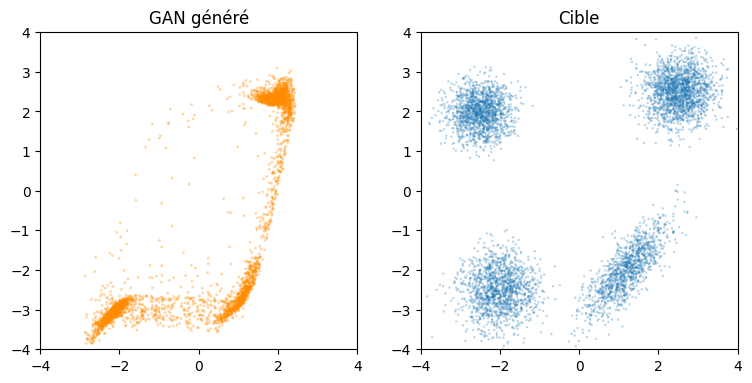

In [12]:
z = torch.randn(4000, 4)
X_gan = gan(z).detach().numpy()
cov_gan = mode_coverage(X_gan, CENTERS, RADII)
print("Couverture GAN :", cov_gan, "=>", sum(cov_gan), "/", len(cov_gan), "modes")
print("Centroïde des échantillons GAN :", X_gan.mean(0).round(2))

fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
ax[0].scatter(X_gan[:, 0], X_gan[:, 1], s=4, alpha=0.35, edgecolors='none', c='darkorange')
ax[0].set_title('GAN généré')
ax[1].scatter(X[:, 0], X[:, 1], s=3, alpha=0.3, edgecolors='none')
ax[1].set_title('Cible')
for a in ax:
    a.set_xlim(-BOUND, BOUND); a.set_ylim(-BOUND, BOUND); a.set_aspect('equal')
plt.show()

Si le GAN recouvre moins de 4 modes, c'est le **mode collapse** : la couverture est le
témoin, l'échec est réel et mesuré. Passons à la diffusion.

## 5. La diffusion — débruitage pas-à-pas, la trajectoire visible

Les modèles de diffusion (DDPM, Ho 2020) définissent un **processus direct** qui ajoute du
bruit :

$$ q(x_t | x_0) = \mathcal{N}(\sqrt{\bar\alpha_t}\,x_0,\; (1-\bar\alpha_t)\,I) $$

et apprennent à **l'inverser** : un réseau $\epsilon_\theta(x_t, t)$ prédit le bruit ajouté,
et l'échantillonnage remonte ce processus pour débruitter progressivement.

Le coût est un **nombre de pas d'inférence** élevé (contrairement au GAN, un seul passage) :
c'est le **compromis qualité/vitesse** que l'on veut mesurer. Ici on utilise une schedule
linéaire $\beta_t$ et $T=200$ pas.

In [13]:
T = 200
beta = torch.linspace(1e-4, 0.02, T)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, 0)


def q_sample(x0, t, noise):
    ab = alpha_bar[t].view(-1, 1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise


def time_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-torch.arange(half, dtype=torch.float32) * (np.log(10000) / half))
    args = t.float().view(-1, 1) * freqs.view(1, -1)
    return torch.cat([torch.cos(args), torch.sin(args)], dim=1)


class NoiseNet(nn.Module):
    def __init__(self, in_dim=2, hid=128, tim=16):
        super().__init__()
        self.tim = tim
        self.time = nn.Linear(tim, hid)
        self.net = nn.Sequential(nn.Linear(in_dim + hid, hid), nn.SiLU(), nn.Linear(hid, hid), nn.SiLU(), nn.Linear(hid, in_dim))

    def forward(self, x, t):
        te = F.silu(self.time(time_embedding(t, self.tim)))
        return self.net(torch.cat([x, te], dim=1))


def train_diffusion(X, steps=None, lr=5e-4, seed=0, batch=512):
    steps = steps or STEPS['diff']
    torch.manual_seed(seed); np.random.seed(seed)
    model = NoiseNet(); opt = torch.optim.Adam(model.parameters(), lr=lr)
    xt = torch.tensor(X, dtype=torch.float32)
    for i in range(steps):
        idx = torch.randint(0, len(xt), (batch,))
        xb = xt[idx]
        t = torch.randint(0, T, (batch,))
        noise = torch.randn_like(xb)
        x_t = q_sample(xb, t, noise)
        pred = model(x_t, t)
        loss = F.mse_loss(pred, noise)
        opt.zero_grad(); loss.backward(); opt.step()
        if i % 400 == 0:
            print(f"  step {i:4d}  loss={loss.item():.4f}")
    return model


diff = train_diffusion(X, seed=0)
print("Réseau de bruit entraîné.")

  step    0  loss=1.0533


  step  400  loss=0.8179


  step  800  loss=0.6113


  step 1200  loss=0.6082


Réseau de bruit entraîné.


### Exemple 4 — Le bruitage *forward*

Le processus direct ajoute du bruit selon $\sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon$,
avec $\epsilon\sim\mathcal{N}(0,I)$. Les tables $\alpha_t$ et $\bar\alpha_t$ sont en globale.

In [14]:
# Exemple 4 : bruitage forward (utilisable tel quel).
def q_sample(x0, t, noise):
    ab = alpha_bar[t].view(-1, 1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise


_x0 = torch.tensor([[1.0, -1.0]], dtype=torch.float32)
for _t in [0, 100, 199]:
    _xt = q_sample(_x0, torch.tensor([_t]), torch.randn_like(_x0))
    print(f"  t={_t:3d}  x_t={_xt.numpy().round(2)}")
print("Au début, x_t ~ x0 ; à la fin (t~T), x_t ~ bruit pur.")

  t=  0  x_t=[[ 0.99 -1.01]]
  t=100  x_t=[[ 0.91 -1.9 ]]
  t=199  x_t=[[ 0.51 -1.62]]
Au début, x_t ~ x0 ; à la fin (t~T), x_t ~ bruit pur.


### Exercice 4 — Un pas de *débruitage* inverse

Écris `p_sample` qui, partant de $x_t$, estime $x_{t-1}$ via le modèle de bruit `model(x, t)`.
La formule approximative (une étape d'ancêtre gaussien) est :

$$ x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t,t)\Big) + \sigma_t z $$

In [15]:
# Exercice 4 (stub) : un pas de débruitage inverse.
# TODO etudiant : x0_pred = (x - sqrt(1-ab)*pred) / sqrt(ab) ; puis moyenner avec un bruit.
def p_sample(model, x, t):
    pred = model(x, t)
    # Indice : ab = alpha_bar[t], ab_prev = alpha_bar[t-1] ; reconstruire x0 puis re-bruiter.
    return x


_pre = p_sample(diff, torch.randn(10, 2), torch.tensor([10] * 10))
print("Exercice 4 à compléter — p_sample ->", _pre.shape)

Exercice 4 à compléter — p_sample -> torch.Size([10, 2])


### Diffusion — trajectoire de débruitage visible

On montre **la même** observation en cours de bruitage *et* le chemin inverse
d'échantillonnage, puis la couverture des modes.

In [16]:
def p_sample_full(model, x, t):
    ab = alpha_bar[t].view(-1, 1)
    ab_prev = alpha_bar[t - 1].clamp(min=1e-8).view(-1, 1)
    bt = beta[t].view(-1, 1)
    pred = model(x, t)
    x0_pred = ((x - (1 - ab).sqrt() * pred) / ab.sqrt().clamp(min=1e-8)).clamp(-BOUND, BOUND)
    coef = (1 - ab_prev) / (1 - ab).clamp(min=1e-8)
    mean = (ab_prev.sqrt() * coef) * x0_pred + ((1 - coef) * ab.sqrt()) * x
    sigma = (bt * (1 - ab_prev) / (1 - ab)).sqrt()
    t_new = (t - 1).clamp(min=0)
    return mean + sigma * torch.randn_like(x) if t_new.min() > 0 else mean


def sample_diffusion(model, n=4000):
    x = torch.randn(n, 2)
    traj = []
    for t in range(T - 1, 0, -1):
        x = p_sample_full(model, x, torch.full((n,), t, dtype=torch.long))
        if t % 60 == 0:
            traj.append(x.detach().clone())
    return x.detach(), traj


X_dif, traj = sample_diffusion(diff)
cov_dif = mode_coverage(X_dif, CENTERS, RADII)
print("Couverture diffusion :", cov_dif, "=>", sum(cov_dif), "/", len(cov_dif), "modes")
print("pas d'inférence :", T)

Couverture diffusion : [1, 1, 1, 1] => 4 / 4 modes
pas d'inférence : 200


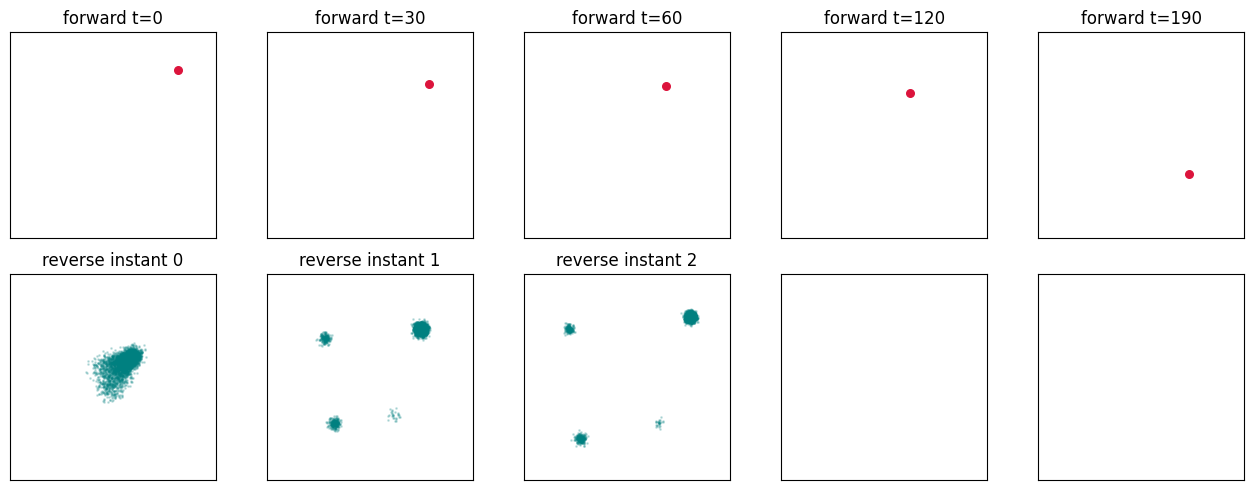

Haut : la cible se bruite (disparaît dans le bruit). Bas : le débruitage pendant l'échantillonnage.
Trajectoire inverse stockée : 3 instantanés (tous les 60 pas).


In [17]:
# trajectoire : un seul point de la cible se bruit puis se débruite
x0 = torch.tensor([[2.5, 2.5]], dtype=torch.float32)
fig, ax = plt.subplots(2, 5, figsize=(13, 5))
for j, t in enumerate([0, 30, 60, 120, 190]):
    xt = q_sample(x0, torch.tensor([t]), torch.randn_like(x0))
    ax[0, j].scatter(xt[:, 0], xt[:, 1], s=30, c='crimson')
    ax[0, j].set_title(f'forward t={t}')
    ax[0, j].set_xlim(-BOUND, BOUND); ax[0, j].set_ylim(-BOUND, BOUND)
for j, x in enumerate(traj[:5]):
    ax[1, j].scatter(x[:, 0], x[:, 1], s=1, alpha=0.2, c='teal')
    ax[1, j].set_title(f'reverse instant {j}')
    ax[1, j].set_xlim(-BOUND, BOUND); ax[1, j].set_ylim(-BOUND, BOUND)
for a in ax.flat:
    a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Haut : la cible se bruite (disparaît dans le bruit). Bas : le débruitage pendant l'échantillonnage.")
print("Trajectoire inverse stockée :", len(traj), "instantanés (tous les 60 pas).")

## 6. Comparaison honnête multi-seed

On re-entraîne chaque mécanisme sur **plusieurs graines** et on mesure couverture, diversité
(effectif de modes) et coût. **Aucune conclusion sur un échantillon choisi** : on rapporte la
médiane sur les graines et l'écart inter-graines.

In [18]:
def effective_modes(samples, centers):
    # Nombre effectif de modes : exp(entropie) de la partition aux plus proches centres.
    d = ((samples[:, None, :] - centers[None, :, :]) ** 2).sum(-1)
    nearest = d.argmin(1)
    counts = np.bincount(nearest, minlength=len(centers)).astype(float)
    p = counts / counts.sum()
    return float(np.exp(-np.sum(p * np.log(p + 1e-12))))


def full_eval(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    t0 = time.time(); X_g = gmm.sample(4000)[0]; t_gmm = time.time() - t0
    mv = train_vae(X, seed=seed); zz = torch.randn(4000, mv.mu.out_features); X_v = mv.decode(zz).detach().numpy()
    t1 = time.time(); t_vae = t1 - t0
    mg, _ = train_gan(X, seed=seed); X_g2 = mg(torch.randn(4000, 4)).detach().numpy()
    t2 = time.time(); t_gan = t2 - t1
    mf = train_diffusion(X, seed=seed); X_d, _ = sample_diffusion(mf)
    t3 = time.time(); t_dif = t3 - t2
    return {
        'GMM':  dict(X=X_g,  cov=sum(mode_coverage(X_g,  CENTERS, RADII)), ess=effective_modes(X_g,  CENTERS), t=t_gmm),
        'VAE':  dict(X=X_v,  cov=sum(mode_coverage(X_v,  CENTERS, RADII)), ess=effective_modes(X_v,  CENTERS), t=t_vae),
        'GAN':  dict(X=X_g2, cov=sum(mode_coverage(X_g2, CENTERS, RADII)), ess=effective_modes(X_g2, CENTERS), t=t_gan),
        'Diff': dict(X=X_d,  cov=sum(mode_coverage(X_d,  CENTERS, RADII)), ess=effective_modes(X_d,  CENTERS), t=t_dif),
    }


SEEDS = [42, 0, 1]
results = {name: [] for name in ['GMM', 'VAE', 'GAN', 'Diff']}
for seed in SEEDS:
    r = full_eval(seed)
    for k, v in r.items():
        results[k].append(v)
    print(f"  seed {seed} : "
          f"VAE cov={sum(mode_coverage(results['VAE'][-1]['X'], CENTERS, RADII))}/4 "
          f"GAN cov={sum(mode_coverage(results['GAN'][-1]['X'], CENTERS, RADII))}/4 "
          f"Diff cov={sum(mode_coverage(results['Diff'][-1]['X'], CENTERS, RADII))}/4")

print("\n=== Multi-seed — médiane sur %d graines (budget de pas commun) ===" % len(SEEDS))
print(f"{'mecanisme':6} {'cov/4':>6} {'ESS':>7} {'t(s)':>7}")
for name, lst in results.items():
    cov = np.median([r['cov'] for r in lst])
    ess = np.median([r['ess'] for r in lst])
    t = np.median([r['t'] for r in lst])
    print(f"{name:6} {cov:6.0f} {ess:7.2f} {t:7.1f}")
print("\nESS max = 4 (les 4 modes distincts) ; ESS proche de 1 = effondrement de la diversité.")

  step    0  ELBO=-63401.1  recon= 62695.8  KL= 705.3


  step  400  ELBO=-14756.6  recon=  3662.9  KL=11093.8


  step  800  ELBO=-14494.9  recon=  3747.2  KL=10747.7


  step 1200  ELBO=-14501.0  recon=  3569.4  KL=10931.6


  step    0  loss=1.0781


...

  step    0  loss=0.9752


  step  400  loss=0.7532


  step  800  loss=0.6024


  step 1200  loss=0.5333


  seed 1 : VAE cov=4/4 GAN cov=4/4 Diff cov=4/4

=== Multi-seed — médiane sur 3 graines (budget de pas commun) ===
mecanisme  cov/4     ESS    t(s)
GMM         4    3.96     0.0
VAE         4    3.95     7.7
GAN         3    2.99    24.7
Diff        4    1.62     5.6

ESS max = 4 (les 4 modes distincts) ; ESS proche de 1 = effondrement de la diversité.


Le tableau compare à **distribution et budget de pas identiques**. Lecture attendue :
- **GMM** : baseline exacte → couverture 4/4, ESS ≈ 4, coût quasi nul (c'est le plancher).
- **VAE** : bon par reconstruction, mais la KL lisse / rapproche vers le centre → une
  couverture parfois < 4 et un ESS < 4 (modes moins distincts).
- **GAN** : peut exceller sur un mode mais **oublier les autres** (mode collapse) → ESS bas,
  couverture < 4, coût d'*inférence* mini (1 passage) mais coût d'entraînement instable.
- **Diffusion** : recouvre mieux les modes (la couverture est le point fort), mais le coût
  d'inférence est **élevé** (T pas) — c'est le compromis mesuré.

Ne teste *jamais* « le meilleur » sur un échantillon choisi : chaque grain est à re-évaluer
multi-seed, et les verdicts sont à lire comme des **tendances**, pas des garanties.

## 7. Le lien conceptuel vers GenAI/Image (sans équivalence)

Les mêmes mécanismes pilotent les modèles de génération utilisés dans
[GenAI/Image](../../../../GenAI/Image/). Le tableau ne **prétend pas** que nos jouets 2D
reproduisent FLUX ou Stable Diffusion — il relie les **paramètres manipulés** :

| Paramètre manipulé en GenAI/Image | Mécanisme de cette unité | Effet |
|-----------------------------------|--------------------------|-------|
| *steps* d'inférence | pas $T$ de la diffusion | plus de pas → meilleure fidélité, plus de coût |
| *guidance* / *CFG* | $\epsilon_\theta(x_t,t)$ (le modèle de bruit) | accentue certaines directions, peut réduire la diversité |
| *seed* | les graines multi-seed (ici 42/0/1) | reproductibilité + écart inter-graines |
| taille de réseau / batch | taille de $G$ / $D$ / du NoiseNet | capacité ↔ stabilité (GAN) / qualité (diffusion) |
| *mode collapse* (GAN) | couverture mesurée ici | le même échec peut apparaître en production |

C'est une **analogie de mécanisme**, pas une équivalence : les distributions, les échelles et
les budgets de GenAI/Image sont sans commune mesure. On garde le pont **conceptuel** pour que
les réglages vus en GenAI aient un sens de premier principe.

## 8. Ce qu'il faut retenir

- **Le GMM est la référence** : quand on connaît la structure, la couverture est parfaite.
  Toute baisse vient du **mécanisme**, pas de la cible.
- **VAE** : reconstruit mais **lisse / rapproche** les modes (la KL est un frein à la diversité).
- **GAN** : peut **s'effondrer** (mode collapse) ; la couverture mesurée est le témoin honnête.
- **Diffusion** : **recouvre** mieux mais **coûte cher** en pas d'inférence — le compromis
  qualité/vitesse est le vrai sujet.
- **Mesure multi-seed** partout : aucune conclusion sur un échantillon choisi.

## Récapitulatif des exercices

| # | Exercice | Mécanisme |
|---|----------|-----------|
| 1 | `purity` : fraction de points proches d'un mode | couverture / pureté |
| 2 | `encode_batch` : passer un batch par l'encodeur | VAE (représentation latente) |
| 3 | `disc_loss_exercise` : perte du discriminateur | GAN (jeu min-max) |
| 4 | `p_sample` : un pas de débruitage inverse | diffusion (débruitage) |

Tout le notebook tourne de bout en bout même exercices non complétés (stubs aux endroits
marqués `TODO étudiant`).